In [3]:
import pyro
import torch
from pyro import distributions as dist
import matplotlib.pyplot as plt
import numpy as np
import random
import arviz as az
from pyro.infer import MCMC, NUTS, Predictive, EmpiricalMarginal
from pyro.infer.autoguide import init_to_mean, init_to_median, init_to_value
from pyro.infer.mcmc.util import summary

from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam



In [4]:

import gempy as gp
import gempy_viewer as gpv

Setting Backend To: AvailableBackends.numpy


/Users/deepprakashravi/miniforge3/envs/gempy_dino/lib/python3.10/site-packages/gempy/core/data/geo_model.py:164: UserWarning: You are using refinement and passing a regular grid. The resolution of the regular grid will be overwritten
  warnings.warn(
/Users/deepprakashravi/miniforge3/envs/gempy_dino/lib/python3.10/site-packages/gempy_viewer/API/_plot_2d_API.py:172: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()
/Users/deepprakashravi/miniforge3/envs/gempy_dino/lib/python3.10/site-packages/gempy_viewer/modules/plot_3d/drawer_surfaces_3d.py:29: PyVistaDeprecationWarning: 
../../../../../miniforge3/envs/gempy_dino/lib/python3.10/site-packages/gempy_viewer/modules/plot_3d/drawer_surfaces_3d.py:29: Argument 'color' must be passed as a keyword argument to function 'BasePlotter.add_mesh'.
From version 0.50, passing this as a positional argument will result in a TypeError.
  gempy_vista.surface_actors[element.name] = gempy_vista.p.add_mesh(


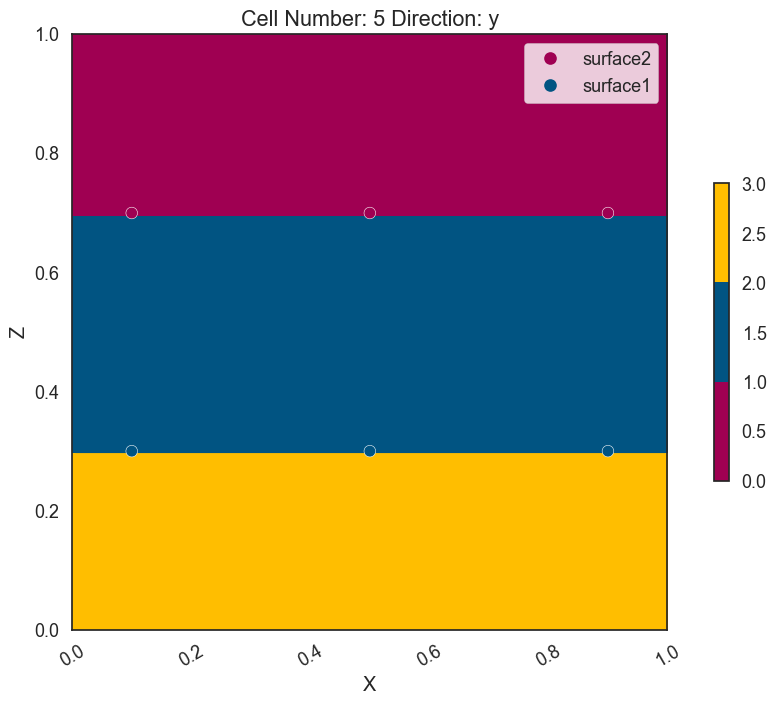

In [ ]:
geo_model_test = gp.create_geomodel(
    project_name='Gempy_abc_Test',  
    extent=[0, 1, -0.1, 0.1, 0, 1], 
    resolution=[100,10,100],             
    refinement=7,
    structural_frame= gp.data.StructuralFrame.initialize_default_structure()
    )
   
brk1 = 0.3
brk2 = 0.7
grad = 1.0
gp.add_surface_points(
    geo_model=geo_model_test,
    x=[0.1, 0.5, 0.9],
    y=[0.0, 0.0, 0.0],
    z=[brk1 , brk1 , brk1],
    elements_names=['surface1', 'surface1', 'surface1']
)

gp.add_orientations(
    geo_model=geo_model_test,
    x=[-0.1, 1.1],
    y=[0.0, 0.0],
    z=[brk1, brk1],
    elements_names=['surface1', 'surface1'],
    pole_vector=[[0, 0, grad], [0, 0, grad]]
)
geo_model_test.update_transform(gp.data.GlobalAnisotropy.NONE)



element2 = gp.data.StructuralElement(
    name='surface2',
    color=next(geo_model_test.structural_frame.color_generator),
    surface_points=gp.data.SurfacePointsTable.from_arrays(
        x=[ 0.1, 0.5, 0.9],
        y=[ 0.0, 0.0, 0.0],
        z=np.array([brk2, brk2, brk2]),
        names='surface2'
    ),
    orientations=gp.data.OrientationsTable.initialize_empty()
)


geo_model_test.update_transform(gp.data.GlobalAnisotropy.NONE)
geo_model_test.structural_frame.structural_groups[0].append_element(element2)

gp.add_orientations(
    geo_model=geo_model_test,
    x=[-0.1, 1.1],
    y=[0.0, 0.0],
    z=[brk2, brk2],
    elements_names=['surface2', 'surface2'],
    pole_vector=[[0, 0, grad], [0, 0, grad]]
)
geo_model_test.update_transform(gp.data.GlobalAnisotropy.NONE)

num_elements = len(geo_model_test.structural_frame.structural_groups[0].elements) - 1  # Number of elements - 1 for zero-based index
for swap_length in range(num_elements, 0, -1):  
    for i in range(swap_length):
        # Perform the swap for each pair (i, i+1)
        geo_model_test.structural_frame.structural_groups[0].elements[i], geo_model_test.structural_frame.structural_groups[0].elements[i + 1] = \
        geo_model_test.structural_frame.structural_groups[0].elements[i + 1], geo_model_test.structural_frame.structural_groups[0].elements[i]

gp.compute_model(geo_model_test)

picture_test = gpv.plot_2d(geo_model_test, cell_number=5, legend='force')
# gpv.plot_3d(geo_model_test, legend='force')